# 01 · Look at the data (Step 1)

Before doing any statistics, check the data with plain SQL:
how many rows, whether anything is blank, how the groups split, and what share of each
group visited, converted, and saw the ad.

The queries live in `sql/` so they can be read and reused on their own. This notebook runs them
through DuckDB and plots the answers.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from abkit.data import FEATURES, connect, default_data_path, is_synthetic, run_sql_file

pd.set_option("display.float_format", "{:,.4f}".format)

DATA = default_data_path()
SYNTHETIC = is_synthetic(DATA)
print(f"Data: {DATA.name}")
if SYNTHETIC:
    print("WARNING: FAKE DATA. Numbers below are made up and are not findings. See data/README.md.")
con = connect(DATA)

Data: criteo-synthetic.parquet


In [2]:
# Chart style: blue = control, orange = treatment, quiet grid, labels in ink colors.
CONTROL, TREATMENT, MUTED = "#2a78d6", "#eb6834", "#86b6ef"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.axisbelow": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "ytick.left": False,
    "font.size": 10, "legend.frameon": False,
})
FAKE_NOTE = "FAKE DATA: illustrative only" if SYNTHETIC else ""

def label_bars(ax, bars, fmt):
    for b in bars:
        ax.annotate(fmt(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", color=INK, fontsize=9)

def pct(x, digits=2):
    return f"{x:.{digits}%}"

## 1. How many rows? Do any rows break the rules?

In [3]:
rows = run_sql_file(con, "01_row_counts.sql")
rows

,n_rows,exposed_but_control,converted_without_visit
0,2000000,0.0000,0.0000


`exposed_but_control` must be 0, because control users are never shown ads.
`converted_without_visit` counts buyers with no recorded visit. We count it rather than assume it is 0.

## 2. Are any values blank?

In [4]:
nulls = run_sql_file(con, "02_missing_values.sql")
print(f"Columns with any NULLs: {(nulls.n_null > 0).sum()} of {len(nulls)}")
nulls

Columns with any NULLs: 0 of 16


,column_name,n_null,share_null
0,f0,0,0.0000
1,f1,0,0.0000
2,f2,0,0.0000
3,f3,0,0.0000
4,f4,0,0.0000
5,f5,0,0.0000
6,f6,0,0.0000
7,f7,0,0.0000
8,f8,0,0.0000
9,f9,0,0.0000


## 3. How many people are in each group?

In [5]:
groups = run_sql_file(con, "03_group_sizes.sql")
groups

,grp,n_users,share_of_users
0,control,299827,0.1499
1,treatment,1700173,0.8501


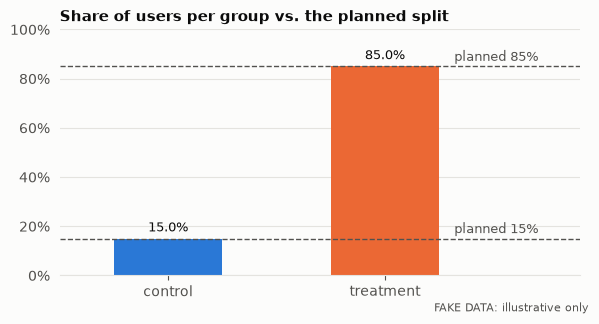

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.2))
colors = [CONTROL if g == "control" else TREATMENT for g in groups.grp]
bars = ax.bar(groups.grp, groups.share_of_users, color=colors, width=0.5)
label_bars(ax, bars, lambda v: pct(v, 1))
ax.axhline(0.85, color=INK_2, lw=1, ls="--"); ax.axhline(0.15, color=INK_2, lw=1, ls="--")
ax.text(1.32, 0.86, "planned 85%", va="bottom", color=INK_2, fontsize=9)
ax.text(1.32, 0.16, "planned 15%", va="bottom", color=INK_2, fontsize=9)
ax.set_xlim(-0.5, 1.9); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Share of users per group vs. the planned split")
fig.text(0.99, 0.01, FAKE_NOTE, ha="right", color=INK_2, fontsize=8)
plt.tight_layout(); plt.show()

Close to the planned 85/15. Step 2 tests this formally (the SRM check).

## 4. Visit, conversion and exposure rates by group

In [7]:
rates = run_sql_file(con, "04_rates_by_group.sql")
rates

,grp,n_users,visit_rate,conversion_rate,exposure_rate,conversion_per_visit
0,control,299827,0.0382,0.0019,0.0000,0.0485
1,treatment,1700173,0.0485,0.0031,0.0362,0.0642
2,"treatment, exposed",61485,0.3862,0.0418,1.0000,0.1084
3,"treatment, not exposed",1638688,0.0358,0.0017,0.0000,0.0463


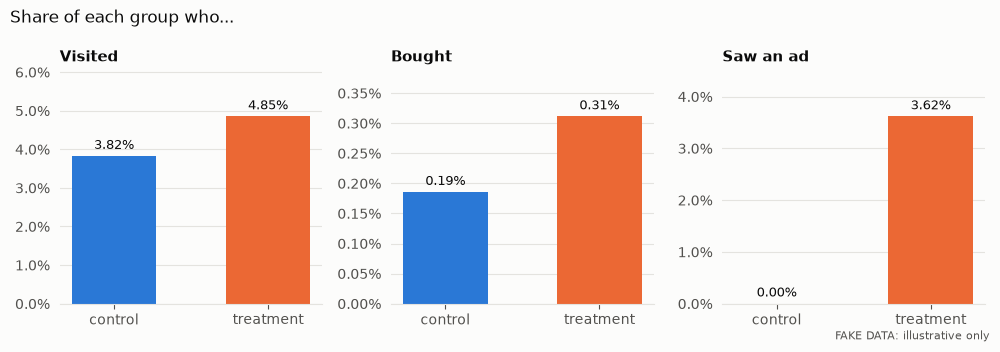

In [8]:
# One small chart per metric. The scales differ a lot, so each gets its own axis.
ab = rates[rates.grp.isin(["control", "treatment"])].set_index("grp").loc[["control", "treatment"]]
metrics = [("visit_rate", "Visited"), ("conversion_rate", "Bought"), ("exposure_rate", "Saw an ad")]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(ab.index, ab[col], color=[CONTROL, TREATMENT], width=0.55)
    label_bars(ax, bars, pct)
    ax.set_title(title)
    ax.set_ylim(0, ab[col].max() * 1.25 or 1)
    digits = 2 if col == "conversion_rate" else 1
    ax.yaxis.set_major_formatter(lambda v, _, d=digits: f"{v:.{d}%}")
fig.suptitle("Share of each group who...", x=0.01, ha="left", color=INK, fontsize=12)
fig.text(0.99, 0.01, FAKE_NOTE, ha="right", color=INK_2, fontsize=8)
plt.tight_layout(); plt.show()

Two things to notice:

* **Purchases are rare.** Only a few people in every 1,000 buy, so effects on conversion will be hard to measure precisely.
* **Most of the treatment group never saw an ad.** Being *put in* the ad group is not the same as *seeing* an ad.

## 5. Preview: why exposure needs care

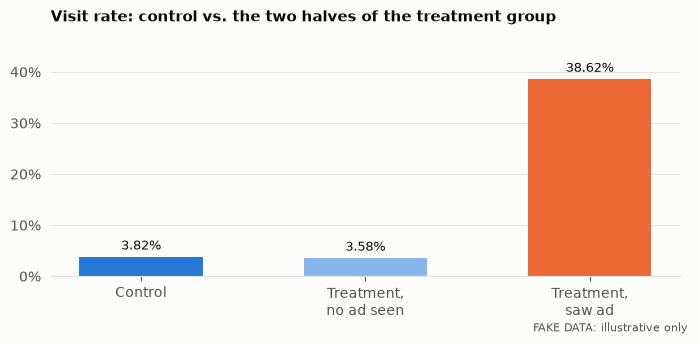

In [9]:
order = ["control", "treatment, not exposed", "treatment, exposed"]
ex = rates.set_index("grp").loc[order]

fig, ax = plt.subplots(figsize=(7, 3.4))
bars = ax.bar(["Control", "Treatment,\nno ad seen", "Treatment,\nsaw ad"], ex.visit_rate,
              color=[CONTROL, MUTED, TREATMENT], width=0.55)
label_bars(ax, bars, pct)
ax.set_ylim(0, ex.visit_rate.max() * 1.25)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Visit rate: control vs. the two halves of the treatment group")
fig.text(0.99, 0.01, FAKE_NOTE, ha="right", color=INK_2, fontsize=8)
plt.tight_layout(); plt.show()

People who saw an ad visit far more often. **This is not the ad's effect.** The ad system chooses who
sees an ad, and it tends to pick people who were already more active. Comparing "saw the ad" with control
mixes the ad's effect with who those people are. Step 2 checks this, and Step 5 handles it properly
(intent-to-treat and the IV estimate).

## 6. Preview: do the groups look alike before the ad?

In [10]:
# Average of each feature by group, with the gap measured in standard deviations.
feat = con.execute(f"""
    SELECT treatment, {", ".join(f"AVG({f}) AS {f}" for f in FEATURES)}
    FROM criteo GROUP BY treatment ORDER BY treatment
""").df().set_index("treatment").T
sd = con.execute(f"SELECT {', '.join(f'STDDEV({f}) AS {f}' for f in FEATURES)} FROM criteo").df().T[0]
feat.columns = ["control_mean", "treatment_mean"]
feat["diff_in_sd"] = (feat.treatment_mean - feat.control_mean) / sd
feat

,control_mean,treatment_mean,diff_in_sd
f0,10.0059,9.9989,-0.0023
f1,23.4053,23.4021,-0.0017
f2,29.9883,30.0023,0.0046
f3,40.0015,39.9987,-0.0009
f4,50.0058,50.0028,-0.0010
f5,63.3989,63.4005,0.0009
f6,70.0051,70.0014,-0.0013
f7,79.9943,79.9965,0.0007
f8,89.9992,89.9998,0.0002
f9,103.4001,103.3986,-0.0008


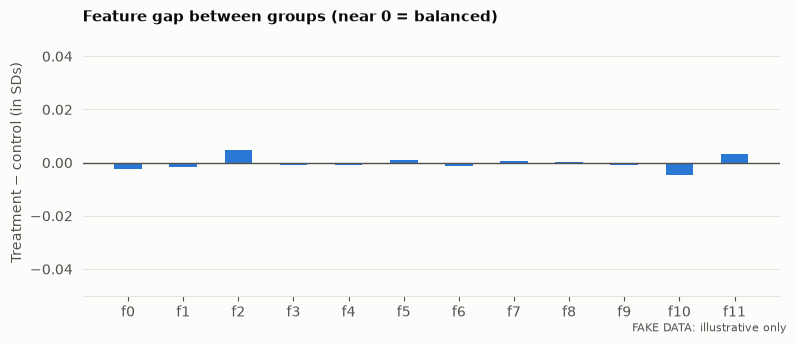

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(feat.index, feat.diff_in_sd, color=CONTROL, width=0.5)
ax.axhline(0, color=INK_2, lw=1)
lim = max(0.05, feat.diff_in_sd.abs().max() * 1.3)
ax.set_ylim(-lim, lim)
ax.set_ylabel("Treatment − control (in SDs)")
ax.set_title("Feature gap between groups (near 0 = balanced)")
fig.text(0.99, 0.01, FAKE_NOTE, ha="right", color=INK_2, fontsize=8)
plt.tight_layout(); plt.show()

All gaps are tiny, which is what a fair coin flip should give. Step 2 turns this into formal balance checks.

## Summary

| Question | Answer |
|---|---|
| Rows | see table 1 |
| Blank values | see table 2 |
| Split | close to the planned 85/15 |
| Purchases | rare, a few per 1,000 |
| Exposure | only a small share of the treatment group saw an ad, and they are not typical users |

**If the data above is synthetic, re-run this notebook after `scripts/download_criteo.py` to get real numbers.**